# Project Setup and Data Loading

In [111]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings

# Suppressing warning messages for cleaner output

warnings.filterwarnings("ignore")

# Setting display options for better readability

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries are being imported successfully.")

Libraries are being imported successfully.


In [112]:
# Loading the uploaded dataset

df = pd.read_csv("SampleSuperstore.csv")

print("Dataset is being loaded successfully.")

Dataset is being loaded successfully.


In [113]:
# Displaying the first five records

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52


In [114]:
# Displaying the last five records

df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.25,3,0.20,4.10
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.96,2,0.00,15.63
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.58,2,0.20,19.39
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.60,4,0.00,13.32
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.16,2,0.00,72.95


In [115]:
# Displaying the number of rows and columns

rows, columns = df.shape

print(f"Number of Rows : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows : 9994
Number of Columns : 13


In [116]:
# Displaying all column names

print("Dataset columns are being displayed.")

df.columns.tolist()

Dataset columns are being displayed.


['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Category',
 'Sub-Category',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [117]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [118]:
# Displaying data types of all columns

df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [119]:
# Displaying descriptive statistics for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,9994.00,55190.38,32063.69,1040.00,23223.00,56430.50,90008.00,99301.00
Sales,9994.00,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
Quantity,9994.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9994.00,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9994.00,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98


In [120]:
# Displaying descriptive statistics for all columns

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,9994,49,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,9994.00,NaN,NaN,NaN,55190.38,32063.69,1040.00,23223.00,56430.50,90008.00,99301.00
Region,9994,4,West,3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,9994,3,Office Supplies,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-Category,9994,17,Binders,1523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales,9994.00,NaN,NaN,NaN,229.86,623.25,0.44,17.28,54.49,209.94,22638.48


In [121]:
# Calculating dataset memory usage

memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Memory Usage : {memory_usage:.2f} MB")

Dataset Memory Usage : 4.85 MB


In [122]:
# Counting numerical and categorical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print(f"Number of Numerical Columns : {len(numerical_columns)}")
print(f"Number of Categorical Columns : {len(categorical_columns)}")

Number of Numerical Columns : 5
Number of Categorical Columns : 8


In [123]:
# Displaying numerical columns

print("Numerical columns are being listed.")

list(numerical_columns)

Numerical columns are being listed.


['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']

In [124]:
# Displaying categorical columns

print("Categorical columns are being listed.")

list(categorical_columns)

Categorical columns are being listed.


['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Category',
 'Sub-Category']

In [125]:
# Creating an initial dataset summary

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Ship Mode,object,0,4
Segment,object,0,3
Country,object,0,1
City,object,0,531
State,object,0,49
Postal Code,int64,0,631
Region,object,0,4
Category,object,0,3
Sub-Category,object,0,17
Sales,float64,0,5825


# Data Exploration and Data Cleaning

In [126]:
# Checking missing values in each column

missing_values = df.isnull().sum()

print("Missing values are being displayed.")

missing_values

Missing values are being displayed.


,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [127]:
# Calculating missing value percentages

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
Ship Mode,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00
State,0,0.00
Postal Code,0,0.00
Region,0,0.00
Category,0,0.00
Sub-Category,0,0.00
Sales,0,0.00


In [128]:
# Checking duplicate records

duplicate_count = df.duplicated().sum()

print(f"Number of Duplicate Records : {duplicate_count}")

Number of Duplicate Records : 17


In [129]:
# Displaying duplicate records

duplicates = df[df.duplicated()]

duplicates.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.55,3,0.20,5.44
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.37,2,0.30,-12.06
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.37,2,0.20,3.63
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.44,3,0.00,9.33
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.84,3,0.00,5.78


In [130]:
# Removing duplicate records

df = df.drop_duplicates()

print("Duplicate records are being removed.")

print(f"Remaining Records : {len(df)}")

Duplicate records are being removed.
Remaining Records : 9977


In [131]:
# Confirming duplicate removal

print(f"Remaining Duplicate Records : {df.duplicated().sum()}")

Remaining Duplicate Records : 0


In [132]:
# Displaying updated data types

df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [133]:
# Renaming columns for easier SQL operations

df.rename(columns={
    "Ship Mode": "Ship_Mode",
    "Postal Code": "Postal_Code",
    "Sub-Category": "Sub_Category"
}, inplace=True)

print("Column names are being updated.")

Column names are being updated.


In [134]:
# Displaying updated column names

df.columns.tolist()

['Ship_Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal_Code',
 'Region',
 'Category',
 'Sub_Category',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [135]:
# Displaying unique value counts

unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
Ship_Mode,4
Segment,3
Country,1
City,531
State,49
Postal_Code,631
Region,4
Category,3
Sub_Category,17
Sales,5825


In [136]:
# Displaying unique values for categorical columns

for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}")
    print(df[column].unique())


Ship_Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment
['Consumer' 'Corporate' 'Home Office']

Country
['United States']

City
['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood' 'Chapel Hill'
 'Mo

In [137]:
# Displaying statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal_Code,9977.00,55154.96,32058.27,1040.00,23223.00,55901.00,90008.00,99301.00
Sales,9977.00,230.15,623.72,0.44,17.30,54.82,209.97,22638.48
Quantity,9977.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9977.00,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9977.00,28.69,234.46,-6599.98,1.73,8.67,29.37,8399.98


In [138]:
# Detecting outliers using the IQR method

numerical_columns = ["Sales", "Quantity", "Discount", "Profit"]

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]

    outlier_summary.append({
        "Column": column,
        "Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Outliers
0,Sales,1167
1,Quantity,170
2,Discount,855
3,Profit,1881


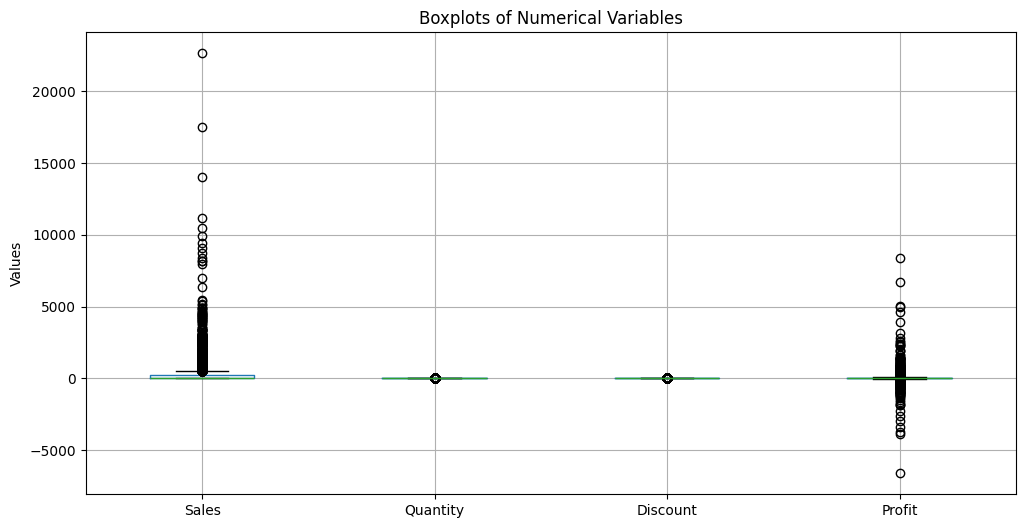

In [139]:
# Displaying boxplots for numerical columns

plt.figure(figsize=(12,6))

df[["Sales","Quantity","Discount","Profit"]].boxplot()

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Values")

plt.show()

In [140]:
# Checking transactions with negative profit

negative_profit = df[df["Profit"] < 0]

print(f"Negative Profit Transactions : {len(negative_profit)}")

Negative Profit Transactions : 1869


In [141]:
# Checking transactions with zero sales

zero_sales = df[df["Sales"] == 0]

print(f"Zero Sales Transactions : {len(zero_sales)}")

Zero Sales Transactions : 0


In [142]:
# Displaying available discount values

sorted(df["Discount"].unique())

[np.float64(0.0),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.32),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7),
 np.float64(0.8)]

In [143]:
# Creating a clean copy of the dataset

clean_df = df.copy()

print("Clean dataset is being created.")

Clean dataset is being created.


In [144]:
# Saving the cleaned dataset

clean_df.to_csv("Cleaned_SampleSuperstore.csv", index=False)

print("Cleaned dataset is being saved successfully.")

Cleaned dataset is being saved successfully.


In [145]:
# Displaying final dataset information

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship_Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal_Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub_Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


# SQLite Database Creation

In [146]:
# Importing the SQLite library

import sqlite3

In [147]:
# Creating a SQLite database

connection = sqlite3.connect("Ecommerce_Analytics.db")

print("SQLite database is being created successfully.")

SQLite database is being created successfully.


In [148]:
# Creating a database cursor

cursor = connection.cursor()

print("Database cursor is being created.")

Database cursor is being created.


In [149]:
# Displaying the SQLite version

cursor.execute("SELECT sqlite_version();")

print("SQLite Version :", cursor.fetchone()[0])

SQLite Version : 3.37.2


In [150]:
# Storing the cleaned dataset in the database

clean_df.to_sql(
    name="sales_data",
    con=connection,
    if_exists="replace",
    index=False
)

print("Dataset is being stored successfully.")

Dataset is being stored successfully.


In [151]:
# Checking available tables

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", connection)

tables

,name
0,sales_data


In [152]:
# Displaying the table structure

table_info = pd.read_sql("""
PRAGMA table_info(sales_data);
""", connection)

table_info

,cid,name,type,notnull,dflt_value,pk
0,0,Ship_Mode,TEXT,0,None,0
1,1,Segment,TEXT,0,None,0
2,2,Country,TEXT,0,None,0
3,3,City,TEXT,0,None,0
4,4,State,TEXT,0,None,0
5,5,Postal_Code,INTEGER,0,None,0
6,6,Region,TEXT,0,None,0
7,7,Category,TEXT,0,None,0
8,8,Sub_Category,TEXT,0,None,0
9,9,Sales,REAL,0,None,0


In [153]:
# Counting total records

record_count = pd.read_sql("""
SELECT COUNT(*) AS Total_Records
FROM sales_data;
""", connection)

record_count

,Total_Records
0,9977


In [154]:
# Displaying sample records

sample_records = pd.read_sql("""
SELECT *
FROM sales_data
LIMIT 10;
""", connection)

sample_records

,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.86,7,0.00,14.17
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.28,4,0.00,1.97
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.15,6,0.20,90.72
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.50,3,0.20,5.78
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.90,5,0.00,34.47


In [155]:
# Displaying column names

columns = pd.read_sql("""
PRAGMA table_info(sales_data);
""", connection)

columns[["name"]]

,name
0,Ship_Mode
1,Segment
2,Country
3,City
4,State
5,Postal_Code
6,Region
7,Category
8,Sub_Category
9,Sales


In [156]:
# Checking missing values

missing_sql = pd.read_sql("""

SELECT

SUM(CASE WHEN Ship_Mode IS NULL THEN 1 ELSE 0 END) AS Ship_Mode,

SUM(CASE WHEN Segment IS NULL THEN 1 ELSE 0 END) AS Segment,

SUM(CASE WHEN Country IS NULL THEN 1 ELSE 0 END) AS Country,

SUM(CASE WHEN City IS NULL THEN 1 ELSE 0 END) AS City,

SUM(CASE WHEN State IS NULL THEN 1 ELSE 0 END) AS State,

SUM(CASE WHEN Postal_Code IS NULL THEN 1 ELSE 0 END) AS Postal_Code,

SUM(CASE WHEN Region IS NULL THEN 1 ELSE 0 END) AS Region,

SUM(CASE WHEN Category IS NULL THEN 1 ELSE 0 END) AS Category,

SUM(CASE WHEN Sub_Category IS NULL THEN 1 ELSE 0 END) AS Sub_Category,

SUM(CASE WHEN Sales IS NULL THEN 1 ELSE 0 END) AS Sales,

SUM(CASE WHEN Quantity IS NULL THEN 1 ELSE 0 END) AS Quantity,

SUM(CASE WHEN Discount IS NULL THEN 1 ELSE 0 END) AS Discount,

SUM(CASE WHEN Profit IS NULL THEN 1 ELSE 0 END) AS Profit

FROM sales_data;

""", connection)

missing_sql

,Ship_Mode,Segment,Country,City,State,Postal_Code,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [157]:
# Displaying summary statistics

summary_sql = pd.read_sql("""

SELECT

COUNT(*) AS Total_Transactions,

SUM(Sales) AS Total_Sales,

SUM(Profit) AS Total_Profit,

SUM(Quantity) AS Total_Quantity,

AVG(Sales) AS Average_Sales,

AVG(Profit) AS Average_Profit,

AVG(Discount) AS Average_Discount

FROM sales_data;

""", connection)

summary_sql

,Total_Transactions,Total_Sales,Total_Profit,Total_Quantity,Average_Sales,Average_Profit,Average_Discount
0,9977,2296195.59,286241.42,37820,230.15,28.69,0.16


In [158]:
# Comparing records between DataFrame and SQLite

python_rows = len(clean_df)

sql_rows = pd.read_sql("""
SELECT COUNT(*) AS Total
FROM sales_data;
""", connection).iloc[0, 0]

print(f"Python DataFrame Rows : {python_rows}")
print(f"SQLite Table Rows : {sql_rows}")

if python_rows == sql_rows:
    print("Database verification is completed successfully.")
else:
    print("Row count mismatch is being detected.")

Python DataFrame Rows : 9977
SQLite Table Rows : 9977
Database verification is completed successfully.


In [159]:
# Creating an index on State

cursor.execute("""

CREATE INDEX IF NOT EXISTS idx_state
ON sales_data(State);

""")

connection.commit()

print("Index is being created successfully.")

Index is being created successfully.


In [160]:
# Creating an index on Category

cursor.execute("""

CREATE INDEX IF NOT EXISTS idx_category
ON sales_data(Category);

""")

connection.commit()

print("Category index is being created.")

Category index is being created.


In [161]:
# Creating an index on Region

cursor.execute("""

CREATE INDEX IF NOT EXISTS idx_region
ON sales_data(Region);

""")

connection.commit()

print("Region index is being created.")

Region index is being created.


In [162]:
# Saving database changes

connection.commit()

print("Database changes are being saved.")

Database changes are being saved.


# SQL Business Analysis

In [163]:
# Calculating total sales

total_sales = pd.read_sql("""

SELECT
ROUND(SUM(Sales), 2) AS Total_Sales
FROM sales_data;

""", connection)

total_sales

,Total_Sales
0,2296195.59


In [164]:
# Calculating total profit

total_profit = pd.read_sql("""

SELECT
ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales_data;

""", connection)

total_profit

,Total_Profit
0,286241.42


In [165]:
# Calculating total quantity sold

total_quantity = pd.read_sql("""

SELECT
SUM(Quantity) AS Total_Quantity
FROM sales_data;

""", connection)

total_quantity

,Total_Quantity
0,37820


In [166]:
# Calculating average sales

average_sales = pd.read_sql("""

SELECT
ROUND(AVG(Sales),2) AS Average_Sales
FROM sales_data;

""", connection)

average_sales

,Average_Sales
0,230.15


In [167]:
# Calculating average profit

average_profit = pd.read_sql("""

SELECT
ROUND(AVG(Profit),2) AS Average_Profit
FROM sales_data;

""", connection)

average_profit

,Average_Profit
0,28.69


In [168]:
# Calculating average discount

average_discount = pd.read_sql("""

SELECT
ROUND(AVG(Discount),2) AS Average_Discount
FROM sales_data;

""", connection)

average_discount

,Average_Discount
0,0.16


In [169]:
# Calculating sales by category

sales_category = pd.read_sql("""

SELECT

Category,
ROUND(SUM(Sales),2) AS Total_Sales

FROM sales_data

GROUP BY Category

ORDER BY Total_Sales DESC;

""", connection)

sales_category

,Category,Total_Sales
0,Technology,836154.03
1,Furniture,741306.31
2,Office Supplies,718735.24


In [170]:
# Calculating profit by category

profit_category = pd.read_sql("""

SELECT

Category,
ROUND(SUM(Profit),2) AS Total_Profit

FROM sales_data

GROUP BY Category

ORDER BY Total_Profit DESC;

""", connection)

profit_category

,Category,Total_Profit
0,Technology,145454.95
1,Office Supplies,122364.66
2,Furniture,18421.81


In [171]:
# Calculating profit by region

profit_region = pd.read_sql("""

SELECT

Region,
ROUND(SUM(Profit),2) AS Total_Profit

FROM sales_data

GROUP BY Region

ORDER BY Total_Profit DESC;

""", connection)

profit_region

,Region,Total_Profit
0,West,108329.81
1,East,91506.31
2,South,46749.43
3,Central,39655.88


In [172]:
# Calculating sales by customer segment

sales_segment = pd.read_sql("""

SELECT

Segment,
ROUND(SUM(Sales),2) AS Total_Sales

FROM sales_data

GROUP BY Segment

ORDER BY Total_Sales DESC;

""", connection)

sales_segment

,Segment,Total_Sales
0,Consumer,1160832.77
1,Corporate,706070.13
2,Home Office,429292.68


In [173]:
# Calculating profit by customer segment

profit_segment = pd.read_sql("""

SELECT

Segment,
ROUND(SUM(Profit),2) AS Total_Profit

FROM sales_data

GROUP BY Segment

ORDER BY Total_Profit DESC;

""", connection)

profit_segment

,Segment,Total_Profit
0,Consumer,134007.44
1,Corporate,91954.98
2,Home Office,60279.00


In [174]:
# Displaying the highest sales states

top_states = pd.read_sql("""

SELECT

State,
ROUND(SUM(Sales),2) AS Total_Sales

FROM sales_data

GROUP BY State

ORDER BY Total_Sales DESC

LIMIT 10;

""", connection)

top_states

,State,Total_Sales
0,California,457576.27
1,New York,310827.15
2,Texas,170124.54
3,Washington,138560.81
4,Pennsylvania,116496.36
5,Florida,89473.71
6,Illinois,80162.54
7,Ohio,77976.76
8,Michigan,75879.64
9,Virginia,70636.72


In [175]:
# Displaying the highest sales cities

top_cities = pd.read_sql("""

SELECT

City,
ROUND(SUM(Sales),2) AS Total_Sales

FROM sales_data

GROUP BY City

ORDER BY Total_Sales DESC

LIMIT 10;

""", connection)

top_cities

,City,Total_Sales
0,New York City,256319.04
1,Los Angeles,175831.90
2,Seattle,119460.28
3,San Francisco,112577.17
4,Philadelphia,109061.46
5,Houston,64441.26
6,Chicago,48535.98
7,San Diego,47521.03
8,Jacksonville,44713.18
9,Springfield,43054.34


In [176]:
# Calculating sales by sub category

sales_subcategory = pd.read_sql("""

SELECT

Sub_Category,
ROUND(SUM(Sales),2) AS Total_Sales

FROM sales_data

GROUP BY Sub_Category

ORDER BY Total_Sales DESC;

""", connection)

sales_subcategory

,Sub_Category,Total_Sales
0,Phones,330007.05
1,Chairs,327777.76
2,Storage,223843.61
3,Tables,206965.53
4,Binders,203409.17
5,Machines,189238.63
6,Accessories,167380.32
7,Copiers,149528.03
8,Bookcases,114880.00
9,Appliances,107532.16


In [177]:
# Calculating profit by sub category

profit_subcategory = pd.read_sql("""

SELECT

Sub_Category,
ROUND(SUM(Profit),2) AS Total_Profit

FROM sales_data

GROUP BY Sub_Category

ORDER BY Total_Profit DESC;

""", connection)

profit_subcategory

,Sub_Category,Total_Profit
0,Copiers,55617.82
1,Phones,44515.73
2,Accessories,41936.64
3,Paper,33944.24
4,Binders,30228.00
5,Chairs,26567.13
6,Storage,21278.83
7,Appliances,18138.01
8,Furnishings,13052.72
9,Envelopes,6964.18


In [178]:
# Calculating average sales by region

avg_sales_region = pd.read_sql("""

SELECT

Region,
ROUND(AVG(Sales),2) AS Average_Sales

FROM sales_data

GROUP BY Region

ORDER BY Average_Sales DESC;

""", connection)

avg_sales_region

,Region,Average_Sales
0,South,241.80
1,East,238.47
2,West,227.14
3,Central,215.95


In [179]:
# Calculating average profit by region

avg_profit_region = pd.read_sql("""

SELECT

Region,
ROUND(AVG(Profit),2) AS Average_Profit

FROM sales_data

GROUP BY Region

ORDER BY Average_Profit DESC;

""", connection)

avg_profit_region

,Region,Average_Profit
0,West,33.93
1,East,32.16
2,South,28.86
3,Central,17.10


In [180]:
# Calculating average discount by category

discount_category = pd.read_sql("""

SELECT

Category,
ROUND(AVG(Discount),2) AS Average_Discount

FROM sales_data

GROUP BY Category

ORDER BY Average_Discount DESC;

""", connection)

discount_category

,Category,Average_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


In [181]:
# Calculating profit margin

profit_margin = pd.read_sql("""

SELECT

Category,

ROUND(SUM(Sales),2) AS Sales,

ROUND(SUM(Profit),2) AS Profit,

ROUND((SUM(Profit)/SUM(Sales))*100,2) AS Profit_Margin_Percentage

FROM sales_data

GROUP BY Category

ORDER BY Profit_Margin_Percentage DESC;

""", connection)

profit_margin

,Category,Sales,Profit,Profit_Margin_Percentage
0,Technology,836154.03,145454.95,17.40
1,Office Supplies,718735.24,122364.66,17.02
2,Furniture,741306.31,18421.81,2.49


In [182]:
# Creating a KPI summary table

kpi_summary = pd.read_sql("""

SELECT

ROUND(SUM(Sales),2) AS Total_Sales,

ROUND(SUM(Profit),2) AS Total_Profit,

SUM(Quantity) AS Total_Quantity,

ROUND(AVG(Sales),2) AS Average_Sales,

ROUND(AVG(Profit),2) AS Average_Profit,

ROUND(AVG(Discount),2) AS Average_Discount,

ROUND((SUM(Profit)/SUM(Sales))*100,2) AS Profit_Margin

FROM sales_data;

""", connection)

kpi_summary

,Total_Sales,Total_Profit,Total_Quantity,Average_Sales,Average_Profit,Average_Discount,Profit_Margin
0,2296195.59,286241.42,37820,230.15,28.69,0.16,12.47


In [183]:
# Exporting SQL query results

sales_category.to_csv("Sales_By_Category.csv", index=False)

profit_category.to_csv("Profit_By_Category.csv", index=False)

avg_sales_region.to_csv("Sales_By_Region.csv", index=False)

profit_region.to_csv("Profit_By_Region.csv", index=False)

sales_segment.to_csv("Sales_By_Segment.csv", index=False)

profit_segment.to_csv("Profit_By_Segment.csv", index=False)

sales_subcategory.to_csv("Sales_By_SubCategory.csv", index=False)

profit_subcategory.to_csv("Profit_By_SubCategory.csv", index=False)

top_states.to_csv("Top_States.csv", index=False)

top_cities.to_csv("Top_Cities.csv", index=False)

kpi_summary.to_csv("KPI_Summary.csv", index=False)

print("SQL analysis results are being exported successfully.")

SQL analysis results are being exported successfully.


# Exploratory Data Analysis and Visualization

In [184]:
# Importing visualization libraries

import matplotlib.pyplot as plt

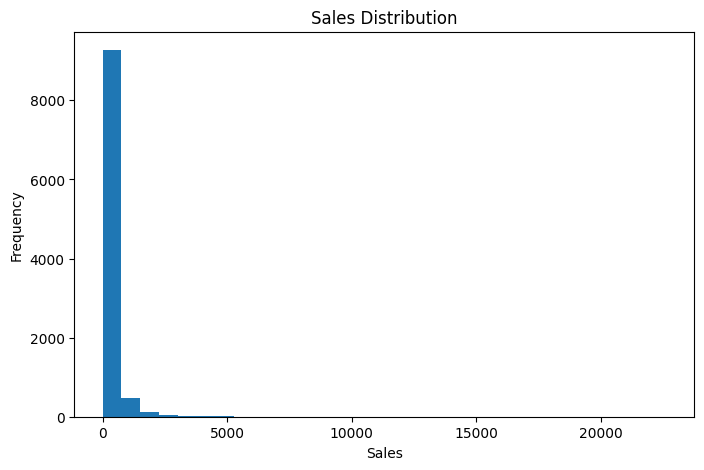

In [185]:
# Displaying the sales distribution

plt.figure(figsize=(8,5))

plt.hist(clean_df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

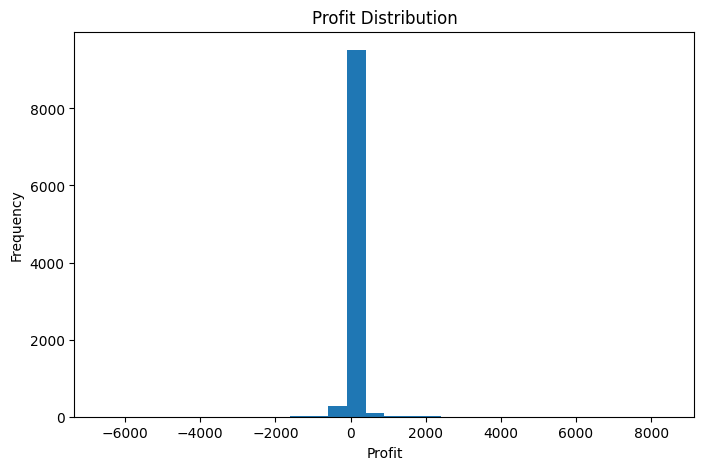

In [186]:
# Displaying the profit distribution

plt.figure(figsize=(8,5))

plt.hist(clean_df["Profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

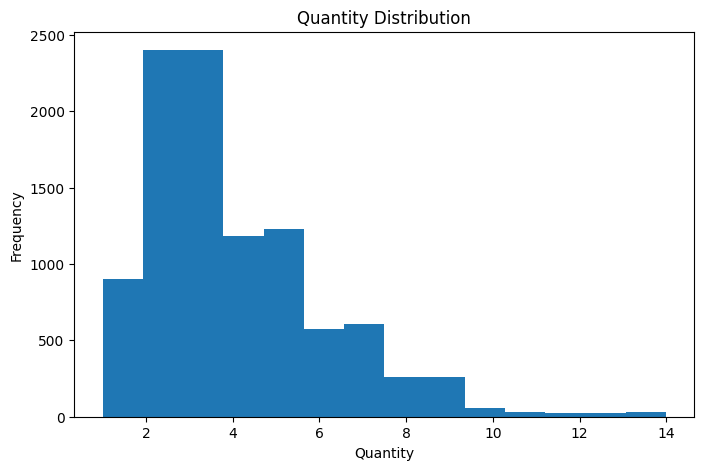

In [187]:
# Displaying the quantity distribution

plt.figure(figsize=(8,5))

plt.hist(clean_df["Quantity"], bins=14)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

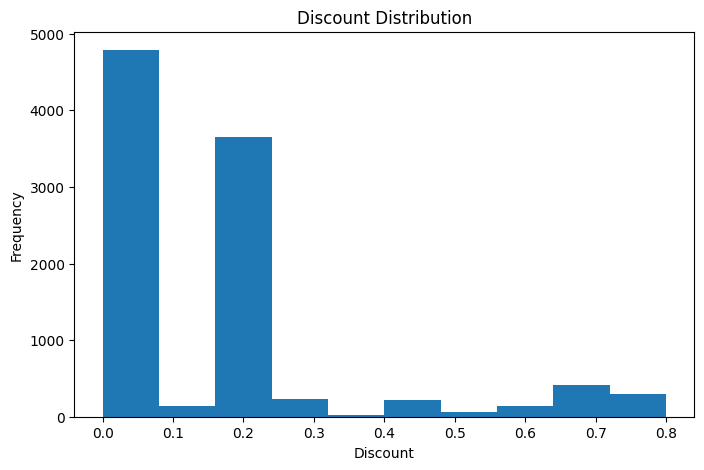

In [188]:
# Displaying the discount distribution

plt.figure(figsize=(8,5))

plt.hist(clean_df["Discount"], bins=10)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.show()

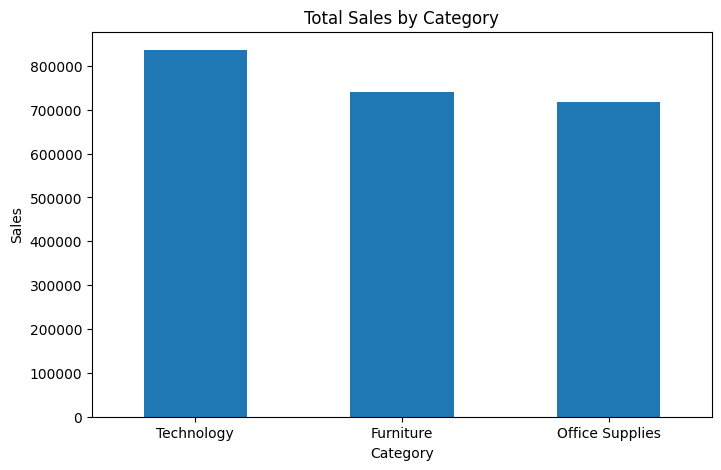

In [189]:
# Displaying sales by category

category_sales = clean_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

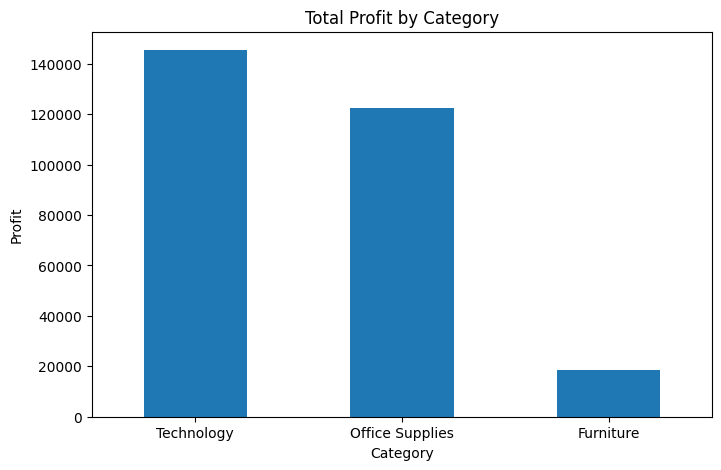

In [190]:
# Displaying profit by category

category_profit = clean_df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

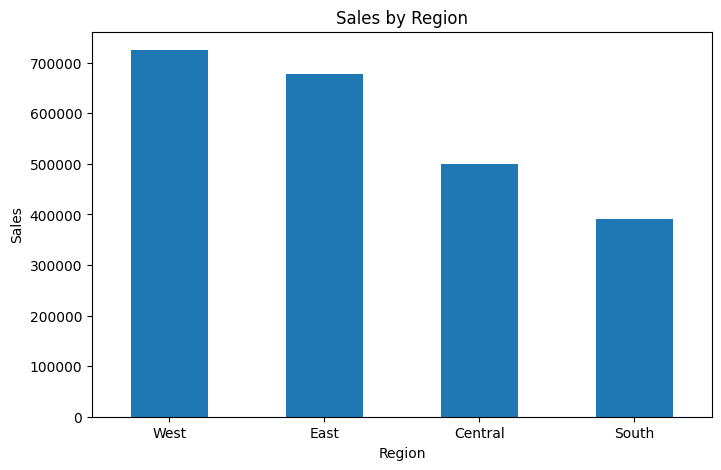

In [191]:
# Displaying sales by region

region_sales = clean_df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

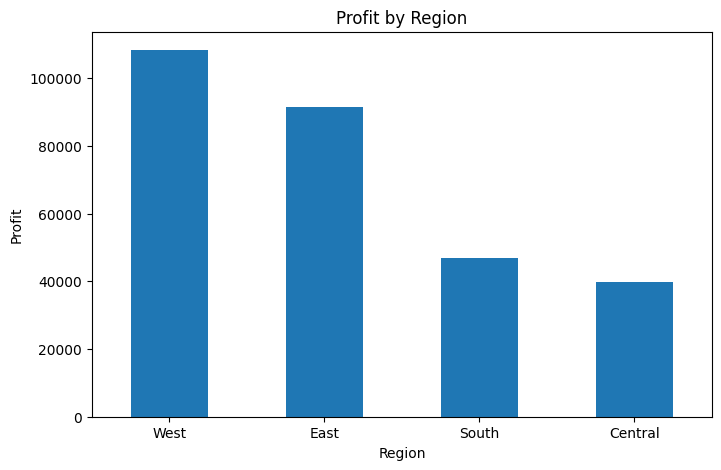

In [192]:
# Displaying profit by region

region_profit = clean_df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

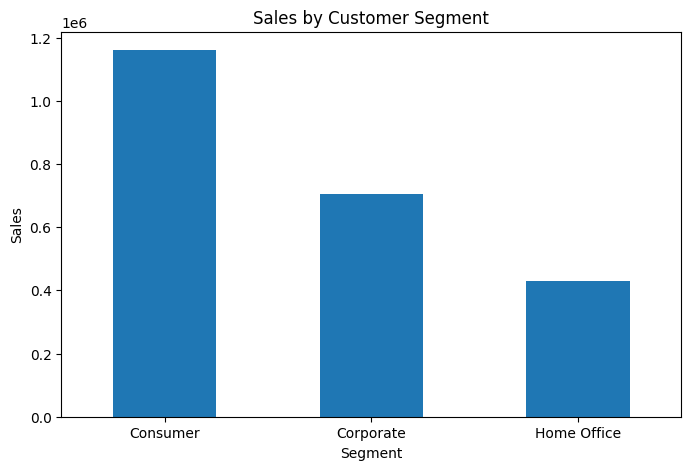

In [193]:
# Displaying sales by customer segment

segment_sales = clean_df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

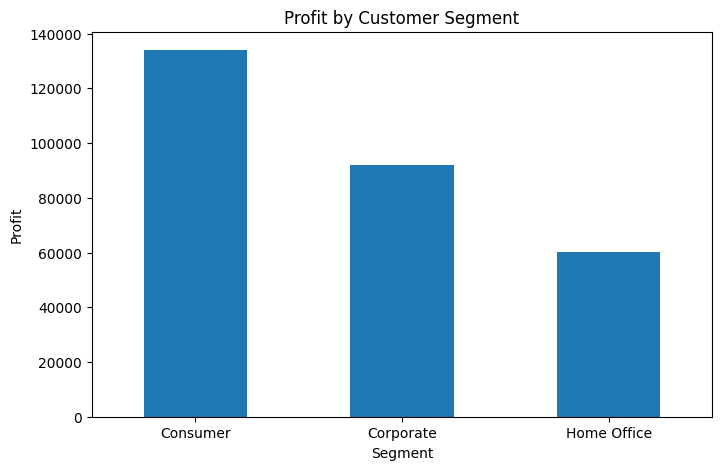

In [194]:
# Displaying profit by customer segment

segment_profit = clean_df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

segment_profit.plot(kind="bar")

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

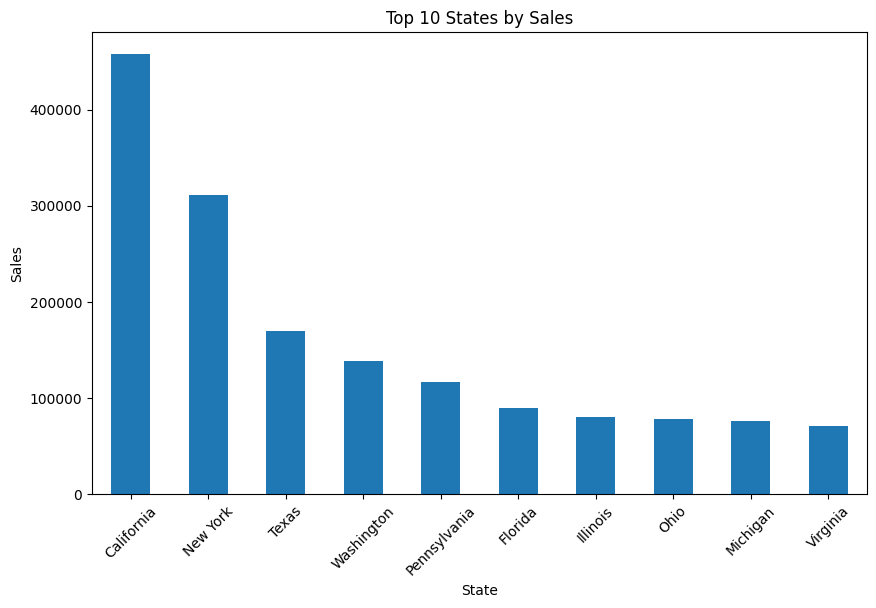

In [195]:
# Displaying the highest sales states

top_states = clean_df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

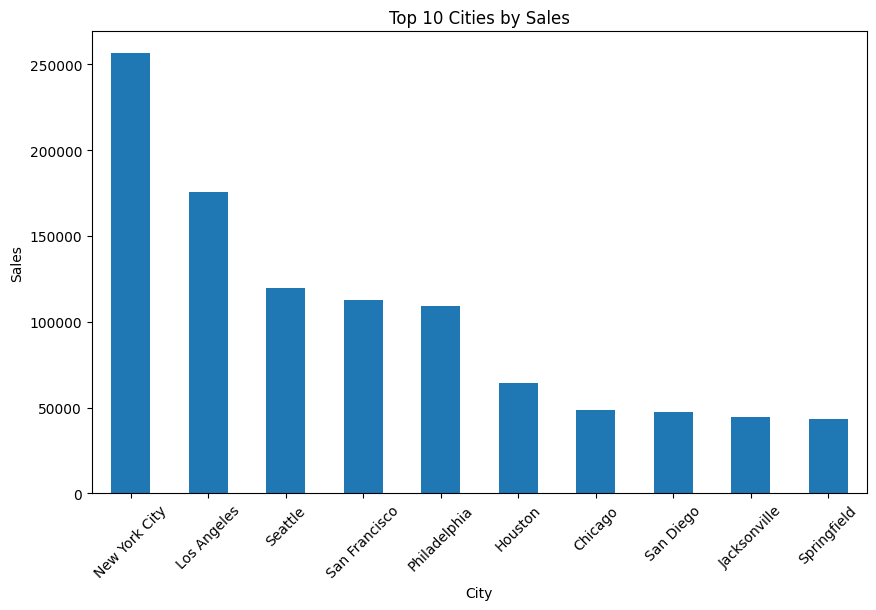

In [196]:
# Displaying the highest sales cities

top_cities = clean_df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

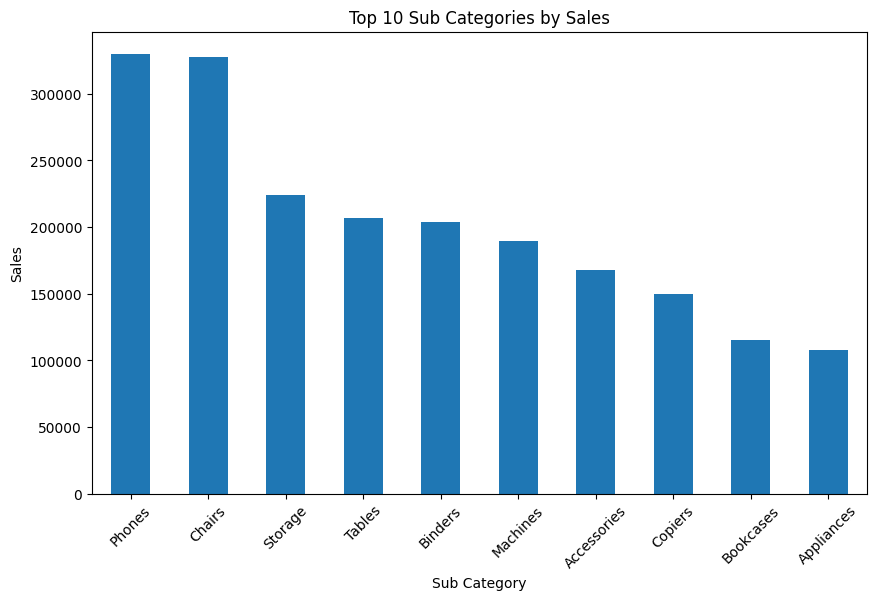

In [197]:
# Displaying sales by sub category

subcategory_sales = clean_df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

subcategory_sales.plot(kind="bar")

plt.title("Top 10 Sub Categories by Sales")
plt.xlabel("Sub Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

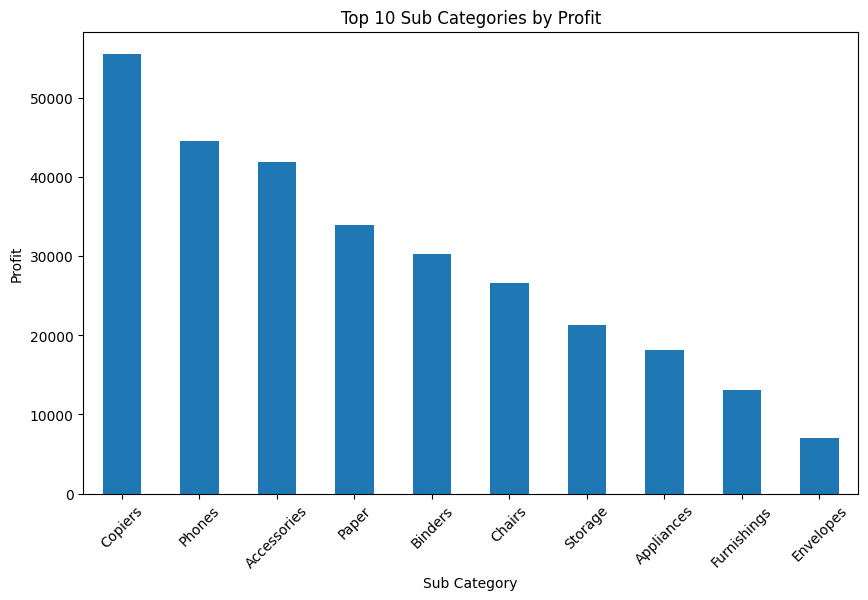

In [198]:
# Displaying profit by sub category

subcategory_profit = clean_df.groupby("Sub_Category")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

subcategory_profit.plot(kind="bar")

plt.title("Top 10 Sub Categories by Profit")
plt.xlabel("Sub Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [199]:
# Displaying the correlation matrix

correlation = clean_df[["Sales","Quantity","Discount","Profit"]].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


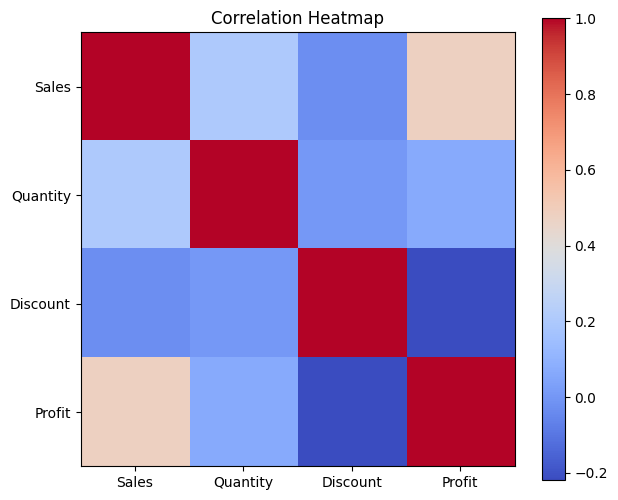

In [200]:
# Displaying the correlation heatmap

plt.figure(figsize=(7,6))

plt.imshow(correlation, cmap="coolwarm")

plt.xticks(range(len(correlation.columns)), correlation.columns)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

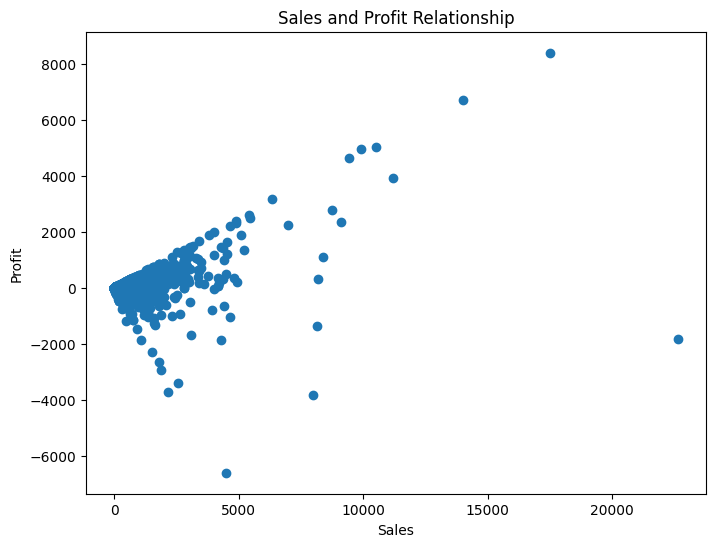

In [201]:
# Displaying the relationship between sales and profit

plt.figure(figsize=(8,6))

plt.scatter(clean_df["Sales"], clean_df["Profit"])

plt.title("Sales and Profit Relationship")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

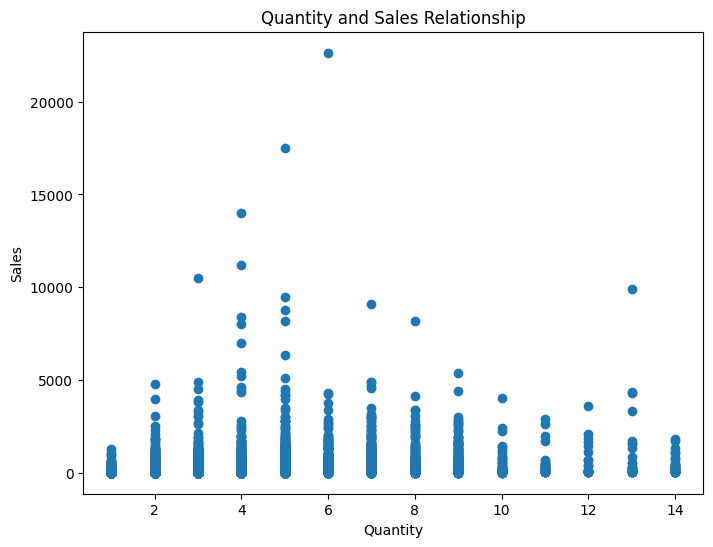

In [202]:
# Displaying the relationship between sales and quantity

plt.figure(figsize=(8,6))

plt.scatter(clean_df["Quantity"], clean_df["Sales"])

plt.title("Quantity and Sales Relationship")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

# Business KPI Analysis

In [203]:
# Calculating overall business KPIs

total_sales = clean_df["Sales"].sum()

total_profit = clean_df["Profit"].sum()

total_quantity = clean_df["Quantity"].sum()

average_sales = clean_df["Sales"].mean()

average_profit = clean_df["Profit"].mean()

average_discount = clean_df["Discount"].mean()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales : {total_sales:.2f}")

print(f"Total Profit : {total_profit:.2f}")

print(f"Total Quantity : {total_quantity}")

print(f"Average Sales : {average_sales:.2f}")

print(f"Average Profit : {average_profit:.2f}")

print(f"Average Discount : {average_discount:.2f}")

print(f"Profit Margin : {profit_margin:.2f}%")

Total Sales : 2296195.59
Total Profit : 286241.42
Total Quantity : 37820
Average Sales : 230.15
Average Profit : 28.69
Average Discount : 0.16
Profit Margin : 12.47%


In [204]:
# Creating a KPI summary table

kpi_summary = pd.DataFrame({

    "Metric":[
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Average Sales",
        "Average Profit",
        "Average Discount",
        "Profit Margin"
    ],

    "Value":[
        round(total_sales,2),
        round(total_profit,2),
        total_quantity,
        round(average_sales,2),
        round(average_profit,2),
        round(average_discount,2),
        round(profit_margin,2)
    ]

})

kpi_summary

,Metric,Value
0,Total Sales,2296195.59
1,Total Profit,286241.42
2,Total Quantity,37820.00
3,Average Sales,230.15
4,Average Profit,28.69
5,Average Discount,0.16
6,Profit Margin,12.47


In [205]:
# Calculating category performance

category_kpi = clean_df.groupby("Category").agg({

    "Sales":"sum",

    "Profit":"sum",

    "Quantity":"sum",

    "Discount":"mean"

}).reset_index()

category_kpi.columns = [

    "Category",

    "Total_Sales",

    "Total_Profit",

    "Total_Quantity",

    "Average_Discount"

]

category_kpi["Profit_Margin"] = (

    category_kpi["Total_Profit"] /

    category_kpi["Total_Sales"]

) * 100

category_kpi

,Category,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Profit_Margin
0,Furniture,741306.31,18421.81,8020,0.17,2.49
1,Office Supplies,718735.24,122364.66,22861,0.16,17.02
2,Technology,836154.03,145454.95,6939,0.13,17.40


In [206]:
# Calculating regional performance

region_kpi = clean_df.groupby("Region").agg({

    "Sales":"sum",

    "Profit":"sum",

    "Quantity":"sum",

    "Discount":"mean"

}).reset_index()

region_kpi.columns = [

    "Region",

    "Total_Sales",

    "Total_Profit",

    "Total_Quantity",

    "Average_Discount"

]

region_kpi["Profit_Margin"] = (

    region_kpi["Total_Profit"] /

    region_kpi["Total_Sales"]

) * 100

region_kpi

,Region,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Profit_Margin
0,Central,500782.85,39655.88,8768,0.24,7.92
1,East,678435.20,91506.31,10609,0.15,13.49
2,South,391721.91,46749.43,6209,0.15,11.93
3,West,725255.64,108329.81,12234,0.11,14.94


In [207]:
# Calculating segment performance

segment_kpi = clean_df.groupby("Segment").agg({

    "Sales":"sum",

    "Profit":"sum",

    "Quantity":"sum",

    "Discount":"mean"

}).reset_index()

segment_kpi.columns = [

    "Segment",

    "Total_Sales",

    "Total_Profit",

    "Total_Quantity",

    "Average_Discount"

]

segment_kpi["Profit_Margin"] = (

    segment_kpi["Total_Profit"] /

    segment_kpi["Total_Sales"]

) * 100

segment_kpi

,Segment,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Profit_Margin
0,Consumer,1160832.77,134007.44,19497,0.16,11.54
1,Corporate,706070.13,91954.98,11591,0.16,13.02
2,Home Office,429292.68,60279.00,6732,0.15,14.04


In [208]:
# Identifying the best performing category

best_category = category_kpi.loc[
    category_kpi["Total_Sales"].idxmax()
]

best_category

,2
Category,Technology
Total_Sales,836154.03
Total_Profit,145454.95
Total_Quantity,6939
Average_Discount,0.13
Profit_Margin,17.40


In [209]:
# Identifying the best performing region

best_region = region_kpi.loc[
    region_kpi["Total_Sales"].idxmax()
]

best_region

,3
Region,West
Total_Sales,725255.64
Total_Profit,108329.81
Total_Quantity,12234
Average_Discount,0.11
Profit_Margin,14.94


In [210]:
# Identifying the most profitable region

profitable_region = region_kpi.loc[
    region_kpi["Total_Profit"].idxmax()
]

profitable_region

,3
Region,West
Total_Sales,725255.64
Total_Profit,108329.81
Total_Quantity,12234
Average_Discount,0.11
Profit_Margin,14.94


In [211]:
# Identifying the best customer segment

best_segment = segment_kpi.loc[
    segment_kpi["Total_Sales"].idxmax()
]

best_segment

,0
Segment,Consumer
Total_Sales,1160832.77
Total_Profit,134007.44
Total_Quantity,19497
Average_Discount,0.16
Profit_Margin,11.54


In [212]:
# Calculating state performance

state_kpi = clean_df.groupby("State").agg({

    "Sales":"sum",

    "Profit":"sum"

}).reset_index()

state_kpi.columns = [

    "State",

    "Total_Sales",

    "Total_Profit"

]

state_kpi = state_kpi.sort_values(

    by="Total_Sales",

    ascending=False

)

state_kpi.head(10)

,State,Total_Sales,Total_Profit
3,California,457576.27,76330.79
30,New York,310827.15,74015.46
41,Texas,170124.54,-25750.98
45,Washington,138560.81,33368.24
36,Pennsylvania,116496.36,-15565.40
8,Florida,89473.71,-3399.30
11,Illinois,80162.54,-12601.65
33,Ohio,77976.76,-16959.32
20,Michigan,75879.64,24428.09
44,Virginia,70636.72,18597.95


In [213]:
# Calculating city performance

city_kpi = clean_df.groupby("City").agg({

    "Sales":"sum",

    "Profit":"sum"

}).reset_index()

city_kpi.columns = [

    "City",

    "Total_Sales",

    "Total_Profit"

]

city_kpi = city_kpi.sort_values(

    by="Total_Sales",

    ascending=False

)

city_kpi.head(10)

,City,Total_Sales,Total_Profit
329,New York City,256319.04,62013.90
266,Los Angeles,175831.90,30431.43
452,Seattle,119460.28,29121.68
438,San Francisco,112577.17,17466.12
374,Philadelphia,109061.46,-13843.21
207,Houston,64441.26,-10175.18
80,Chicago,48535.98,-6648.33
437,San Diego,47521.03,6377.20
216,Jacksonville,44713.18,-2323.84
464,Springfield,43054.34,6200.70


In [214]:
# Creating a business performance summary

business_summary = pd.DataFrame({

    "Business Indicator":[

        "Best Category",

        "Best Region",

        "Best Segment",

        "Highest Sales State",

        "Highest Sales City"

    ],

    "Result":[

        best_category["Category"],

        best_region["Region"],

        best_segment["Segment"],

        state_kpi.iloc[0]["State"],

        city_kpi.iloc[0]["City"]

    ]

})

business_summary

,Business Indicator,Result
0,Best Category,Technology
1,Best Region,West
2,Best Segment,Consumer
3,Highest Sales State,California
4,Highest Sales City,New York City


# Machine Learning Modeling

### Model 1: Regression Model to Predict Profit

In [215]:
# Importing required libraries for regression model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y) for the regression model
# Using numerical features that are likely to influence profit
X_reg = clean_df[['Sales', 'Quantity', 'Discount']]
y_reg = clean_df['Profit']

# Split the data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("Data for regression model is being prepared.")
print(f"Training set size: {len(X_train_reg)}")
print(f"Testing set size: {len(X_test_reg)}")

Data for regression model is being prepared.
Training set size: 7981
Testing set size: 1996


In [216]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

# Make predictions on the test set
y_pred_reg = linear_model.predict(X_test_reg)

print("Linear Regression model is trained and predictions are made.")

Linear Regression model is trained and predictions are made.


In [217]:
# Evaluate the Linear Regression model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display some actual vs. predicted values
regression_results = pd.DataFrame({"Actual Profit": y_test_reg, "Predicted Profit": y_pred_reg})
display(regression_results.head())

Mean Absolute Error (MAE): 59.80
Mean Squared Error (MSE): 62932.16
Root Mean Squared Error (RMSE): 250.86
R-squared (R2): 0.17


,Actual Profit,Predicted Profit
5830,8.09,37.39
5176,19.97,-7.70
6047,-12.92,-151.56
107,2.10,-9.22
3424,41.88,83.98


### Model 2: Classification Model to Predict Profitability

In [218]:
# Create a new target variable: is_profitable (1 if Profit > 0, 0 otherwise)
clean_df['is_profitable'] = (clean_df['Profit'] > 0).astype(int)

# Define features (X) and new target (y) for the classification model
# Using similar features as regression, excluding 'Profit' and 'Postal_Code' for now for simplicity
X_clf = clean_df[['Sales', 'Quantity', 'Discount']]
y_clf = clean_df['is_profitable']

# Split the data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print("Data for classification model is being prepared.")
print(f"Training set size: {len(X_train_clf)}")
print(f"Testing set size: {len(X_test_clf)}")

Data for classification model is being prepared.
Training set size: 7981
Testing set size: 1996


In [219]:
# Importing required libraries for classification model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
logistic_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_clf = logistic_model.predict(X_test_clf)

print("Logistic Regression model is trained and predictions are made.")

Logistic Regression model is trained and predictions are made.


In [220]:
# Evaluate the Logistic Regression model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
class_report = classification_report(y_test_clf, y_pred_clf)
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(class_report)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.61      0.75       372
           1       0.92      1.00      0.96      1624

    accuracy                           0.93      1996
   macro avg       0.95      0.80      0.86      1996
weighted avg       0.93      0.93      0.92      1996


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,227,145
Actual 1,3,1621
